# PRE-ANÁLISIS

In [84]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [6]:
datos = pd.read_csv("diabetic_data.csv")

In [7]:
# display(datos.head()) # primeras 5
# display(datos.dtypes) # tipos
# datos.describe(include='all') # analiza media, std etc
# display(datos.isnull().any()) # valores null
display(datos.info())
# datos.describe()
# display(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

None

In [8]:
datos["readmitted"] = datos["readmitted"].astype("category")
datos["readmitted"] = datos["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

In [9]:
# Reemplazar los valores "?" por NaN (not a number)
datos = datos.replace("?", np.nan)
datos = datos.replace("None", np.nan)


In [10]:
# Quitar IDs (innecesarios para el análisis) y columnas con muchos valores faltantes
datos = datos.drop(columns=['encounter_id', 'patient_nbr'])
datos = datos.drop(columns=['weight'])
datos = datos.drop(columns=['max_glu_serum'])
datos = datos.drop(columns=['A1Cresult'])
datos = datos.drop(columns=['medical_specialty'])
datos = datos.drop(columns=['payer_code'])


Codificar variables categóricas

In [11]:
datos["race"].value_counts() # V. Categórica sin orden, usamos one-hot encoding

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [12]:
datos = pd.get_dummies(datos, columns=['race'], drop_first=True)

In [13]:
datos["gender"].value_counts() # V. Categórica sin orden, usamos one-hot encoding

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [14]:
datos = pd.get_dummies(datos, columns=['gender'], drop_first=True)

In [15]:
datos["age"].value_counts() # V. Categórica con orden, mapearé con valor medio de cada rango

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [16]:
datos["age"] = datos["age"].map({
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
})

In [17]:
display(datos['diag_1'].value_counts().head()) # |
display(datos['diag_2'].value_counts().head()) # | Como tiene tantas categorías, se agruparán por sistemas.
display(datos['diag_3'].value_counts().head()) # |

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
Name: count, dtype: int64

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
Name: count, dtype: int64

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
Name: count, dtype: int64

In [18]:
def seleccionarDiagnostico(codigo):
    cod = str(codigo).strip()
    try:
        codigoFloat = float(cod)
        if 390 <= codigoFloat <= 459 or codigoFloat == 785:
            return 'Circulatorio'
        elif 460 <= codigoFloat <= 519 or codigoFloat == 786:
            return 'Respiratorio'
        elif 520 <= codigoFloat <= 579 or codigoFloat == 787:
            return 'Digestivo'
        elif 250 <= codigoFloat < 251: # Diabetes es 250.xx
            return 'Diabetes'
        elif 800 <= codigoFloat <= 999:
            return 'Lesiones'
        elif 710 <= codigoFloat <= 739:
            return 'Musculoesquelético'
        elif 580 <= codigoFloat <= 629 or codigoFloat == 788:
            return 'Genitourinario'
        elif 140 <= codigoFloat <= 239:
            return 'Neoplasias'
        else:
            return 'Otros'
    except:
        return "Otros"

for col in ['diag_1', 'diag_2', 'diag_3']:
    datos[col] = datos[col].apply(seleccionarDiagnostico)
    datos = pd.get_dummies(datos, columns=[col], drop_first=True)


In [19]:
datos["metformin"].value_counts() 

metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

In [20]:
datos["metformin"] = datos["metformin"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [21]:
datos["repaglinide"].value_counts(normalize="True") 

repaglinide
No        0.984877
Steady    0.013600
Up        0.001081
Down      0.000442
Name: proportion, dtype: float64

In [22]:
datos = datos.drop(columns=['repaglinide'])

In [23]:
datos["nateglinide"].value_counts(normalize="True") 

nateglinide
No        0.993092
Steady    0.006564
Up        0.000236
Down      0.000108
Name: proportion, dtype: float64

In [24]:
datos = datos.drop(columns=['nateglinide'])

In [25]:
datos["chlorpropamide"].value_counts(normalize="True") 

chlorpropamide
No        0.999155
Steady    0.000776
Up        0.000059
Down      0.000010
Name: proportion, dtype: float64

In [26]:
datos = datos.drop(columns=['chlorpropamide'])

In [27]:
datos["glimepiride"].value_counts(normalize="True") 

glimepiride
No        0.948991
Steady    0.045890
Up        0.003213
Down      0.001906
Name: proportion, dtype: float64

In [28]:
datos["glimepiride"] = datos["glimepiride"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [29]:
datos["acetohexamide"].value_counts(normalize="True") 

acetohexamide
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [30]:
datos = datos.drop(columns=['acetohexamide'])

In [31]:
datos["glipizide"].value_counts(normalize="True") 

glipizide
No        0.875341
Steady    0.111589
Up        0.007566
Down      0.005503
Name: proportion, dtype: float64

In [32]:
datos["glipizide"] = datos["glipizide"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [33]:
datos["glyburide"].value_counts(normalize="True") 

glyburide
No        0.895348
Steady    0.091131
Up        0.007979
Down      0.005542
Name: proportion, dtype: float64

In [34]:
datos["glyburide"] = datos["glyburide"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [35]:
datos["tolbutamide"].value_counts(normalize="True") 

tolbutamide
No        0.999774
Steady    0.000226
Name: proportion, dtype: float64

In [36]:
datos = datos.drop(columns=['tolbutamide'])

In [37]:
datos["pioglitazone"].value_counts(normalize="True") 

pioglitazone
No        0.927992
Steady    0.068549
Up        0.002299
Down      0.001160
Name: proportion, dtype: float64

In [38]:
datos["pioglitazone"] = datos["pioglitazone"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [39]:
datos["rosiglitazone"].value_counts(normalize="True") 

rosiglitazone
No        0.937455
Steady    0.059941
Up        0.001749
Down      0.000855
Name: proportion, dtype: float64

In [40]:
datos["rosiglitazone"] = datos["rosiglitazone"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [41]:
datos["acarbose"].value_counts(normalize="True") 

acarbose
No        0.996973
Steady    0.002899
Up        0.000098
Down      0.000029
Name: proportion, dtype: float64

In [42]:
datos = datos.drop(columns=['acarbose'])

In [43]:
datos["miglitol"].value_counts(normalize="True") 

miglitol
No        0.999627
Steady    0.000305
Down      0.000049
Up        0.000020
Name: proportion, dtype: float64

In [44]:
datos = datos.drop(columns=['miglitol'])

In [45]:
datos["troglitazone"].value_counts(normalize="True") 

troglitazone
No        0.999971
Steady    0.000029
Name: proportion, dtype: float64

In [46]:
datos = datos.drop(columns=['troglitazone'])

In [47]:
datos["tolazamide"].value_counts(normalize="True") 

tolazamide
No        0.999617
Steady    0.000373
Up        0.000010
Name: proportion, dtype: float64

In [48]:
datos = datos.drop(columns=['tolazamide'])

In [49]:
datos["examide"].value_counts(normalize="True") 

examide
No    1.0
Name: proportion, dtype: float64

In [50]:
datos = datos.drop(columns=['examide'])

In [51]:
datos["citoglipton"].value_counts(normalize="True") 

citoglipton
No    1.0
Name: proportion, dtype: float64

In [52]:
datos = datos.drop(columns=['citoglipton'])

In [53]:
datos["insulin"].value_counts(normalize="True") 

insulin
No        0.465607
Steady    0.303137
Down      0.120060
Up        0.111196
Name: proportion, dtype: float64

In [54]:
datos["insulin"] = datos["insulin"].map({
    "No": 0,
    "Down": 1,
    "Steady": 2,
    "Up": 3
})

In [55]:
datos["glyburide-metformin"].value_counts(normalize="True") 

glyburide-metformin
No        0.993063
Steady    0.006800
Up        0.000079
Down      0.000059
Name: proportion, dtype: float64

In [56]:
datos = datos.drop(columns=['glyburide-metformin'])

In [57]:
datos["glipizide-metformin"].value_counts(normalize="True") 

glipizide-metformin
No        0.999872
Steady    0.000128
Name: proportion, dtype: float64

In [58]:
datos = datos.drop(columns=['glipizide-metformin'])

In [59]:
datos["glimepiride-pioglitazone"].value_counts(normalize="True") 

glimepiride-pioglitazone
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [60]:
datos = datos.drop(columns=['glimepiride-pioglitazone'])

In [61]:
datos["metformin-rosiglitazone"].value_counts(normalize="True") 

metformin-rosiglitazone
No        0.99998
Steady    0.00002
Name: proportion, dtype: float64

In [62]:
datos = datos.drop(columns=['metformin-rosiglitazone'])

In [63]:
datos["metformin-pioglitazone"].value_counts(normalize="True") 

metformin-pioglitazone
No        0.99999
Steady    0.00001
Name: proportion, dtype: float64

In [64]:
datos = datos.drop(columns=['metformin-pioglitazone'])

In [65]:
datos["change"].value_counts(normalize="True") 

change
No    0.538048
Ch    0.461952
Name: proportion, dtype: float64

In [66]:
datos["change"] = datos["change"].map({
    "No": 0,
    "Ch": 1
})

In [67]:
datos["diabetesMed"].value_counts(normalize="True") 

diabetesMed
Yes    0.770031
No     0.229969
Name: proportion, dtype: float64

In [68]:
datos["diabetesMed"] = datos["diabetesMed"].map({
    "No": 0,
    "Yes": 1
})

In [69]:
datos["insulin"].value_counts()

insulin
0    47383
2    30849
1    12218
3    11316
Name: count, dtype: int64

In [70]:
def transformarAdmTypeId(valor):
    val = str(valor).strip()
    try:
        int(val)
        if valor in [1,2,7]:
            return "Urgencia"
        elif valor == 3:
            return 'Electivo'
        elif valor == 4:
            return 'Recien_Nacido'
        else:
            return 'Otro'
    except:
        return 'Otro'

datos["admission_type_id"] = datos["admission_type_id"].apply(transformarAdmTypeId)
datos = pd.get_dummies(datos, columns=['admission_type_id'], drop_first=True)

In [71]:
# 1. Primero eliminamos los fallecidos (imprescindible)
fallecidos = [11, 13, 14, 19, 20, 21]
datos = datos[~datos['discharge_disposition_id'].isin(fallecidos)] # PREGUNTAR

def agruparDischarge(id):
    if id in [1, 6, 8]:
        return 'Hogar'
    elif id in [2, 3, 4, 5, 9, 10, 15, 22, 23, 24, 27, 28, 29, 30]:
        return 'Traslado'
    else:
        return 'Otros_Desconocido'

datos['discharge_disposition_id'] = datos['discharge_disposition_id'].apply(agruparDischarge)
datos = pd.get_dummies(datos, columns=['discharge_disposition_id'], drop_first=True)

In [72]:
def agruparOrigen(id):
    if id in [1, 2, 3]:
        return 'Referido'
    elif id in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return 'Traslado'
    elif id == 7:
        return 'Urgencias'
    else:
        return 'Otros_Desconocido'

datos['admission_source_id'] = datos['admission_source_id'].apply(agruparOrigen)
datos = pd.get_dummies(datos, columns=['admission_source_id'], drop_first=True)

In [73]:
# onehot transformamos de bool a int
datos = datos.astype({col: int for col in datos.select_dtypes('bool').columns})

In [74]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99343 entries, 0 to 101765
Data columns (total 57 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         99343 non-null  int64
 1   time_in_hospital                            99343 non-null  int64
 2   num_lab_procedures                          99343 non-null  int64
 3   num_procedures                              99343 non-null  int64
 4   num_medications                             99343 non-null  int64
 5   number_outpatient                           99343 non-null  int64
 6   number_emergency                            99343 non-null  int64
 7   number_inpatient                            99343 non-null  int64
 8   number_diagnoses                            99343 non-null  int64
 9   metformin                                   99343 non-null  int64
 10  glimepiride                           

# EDA

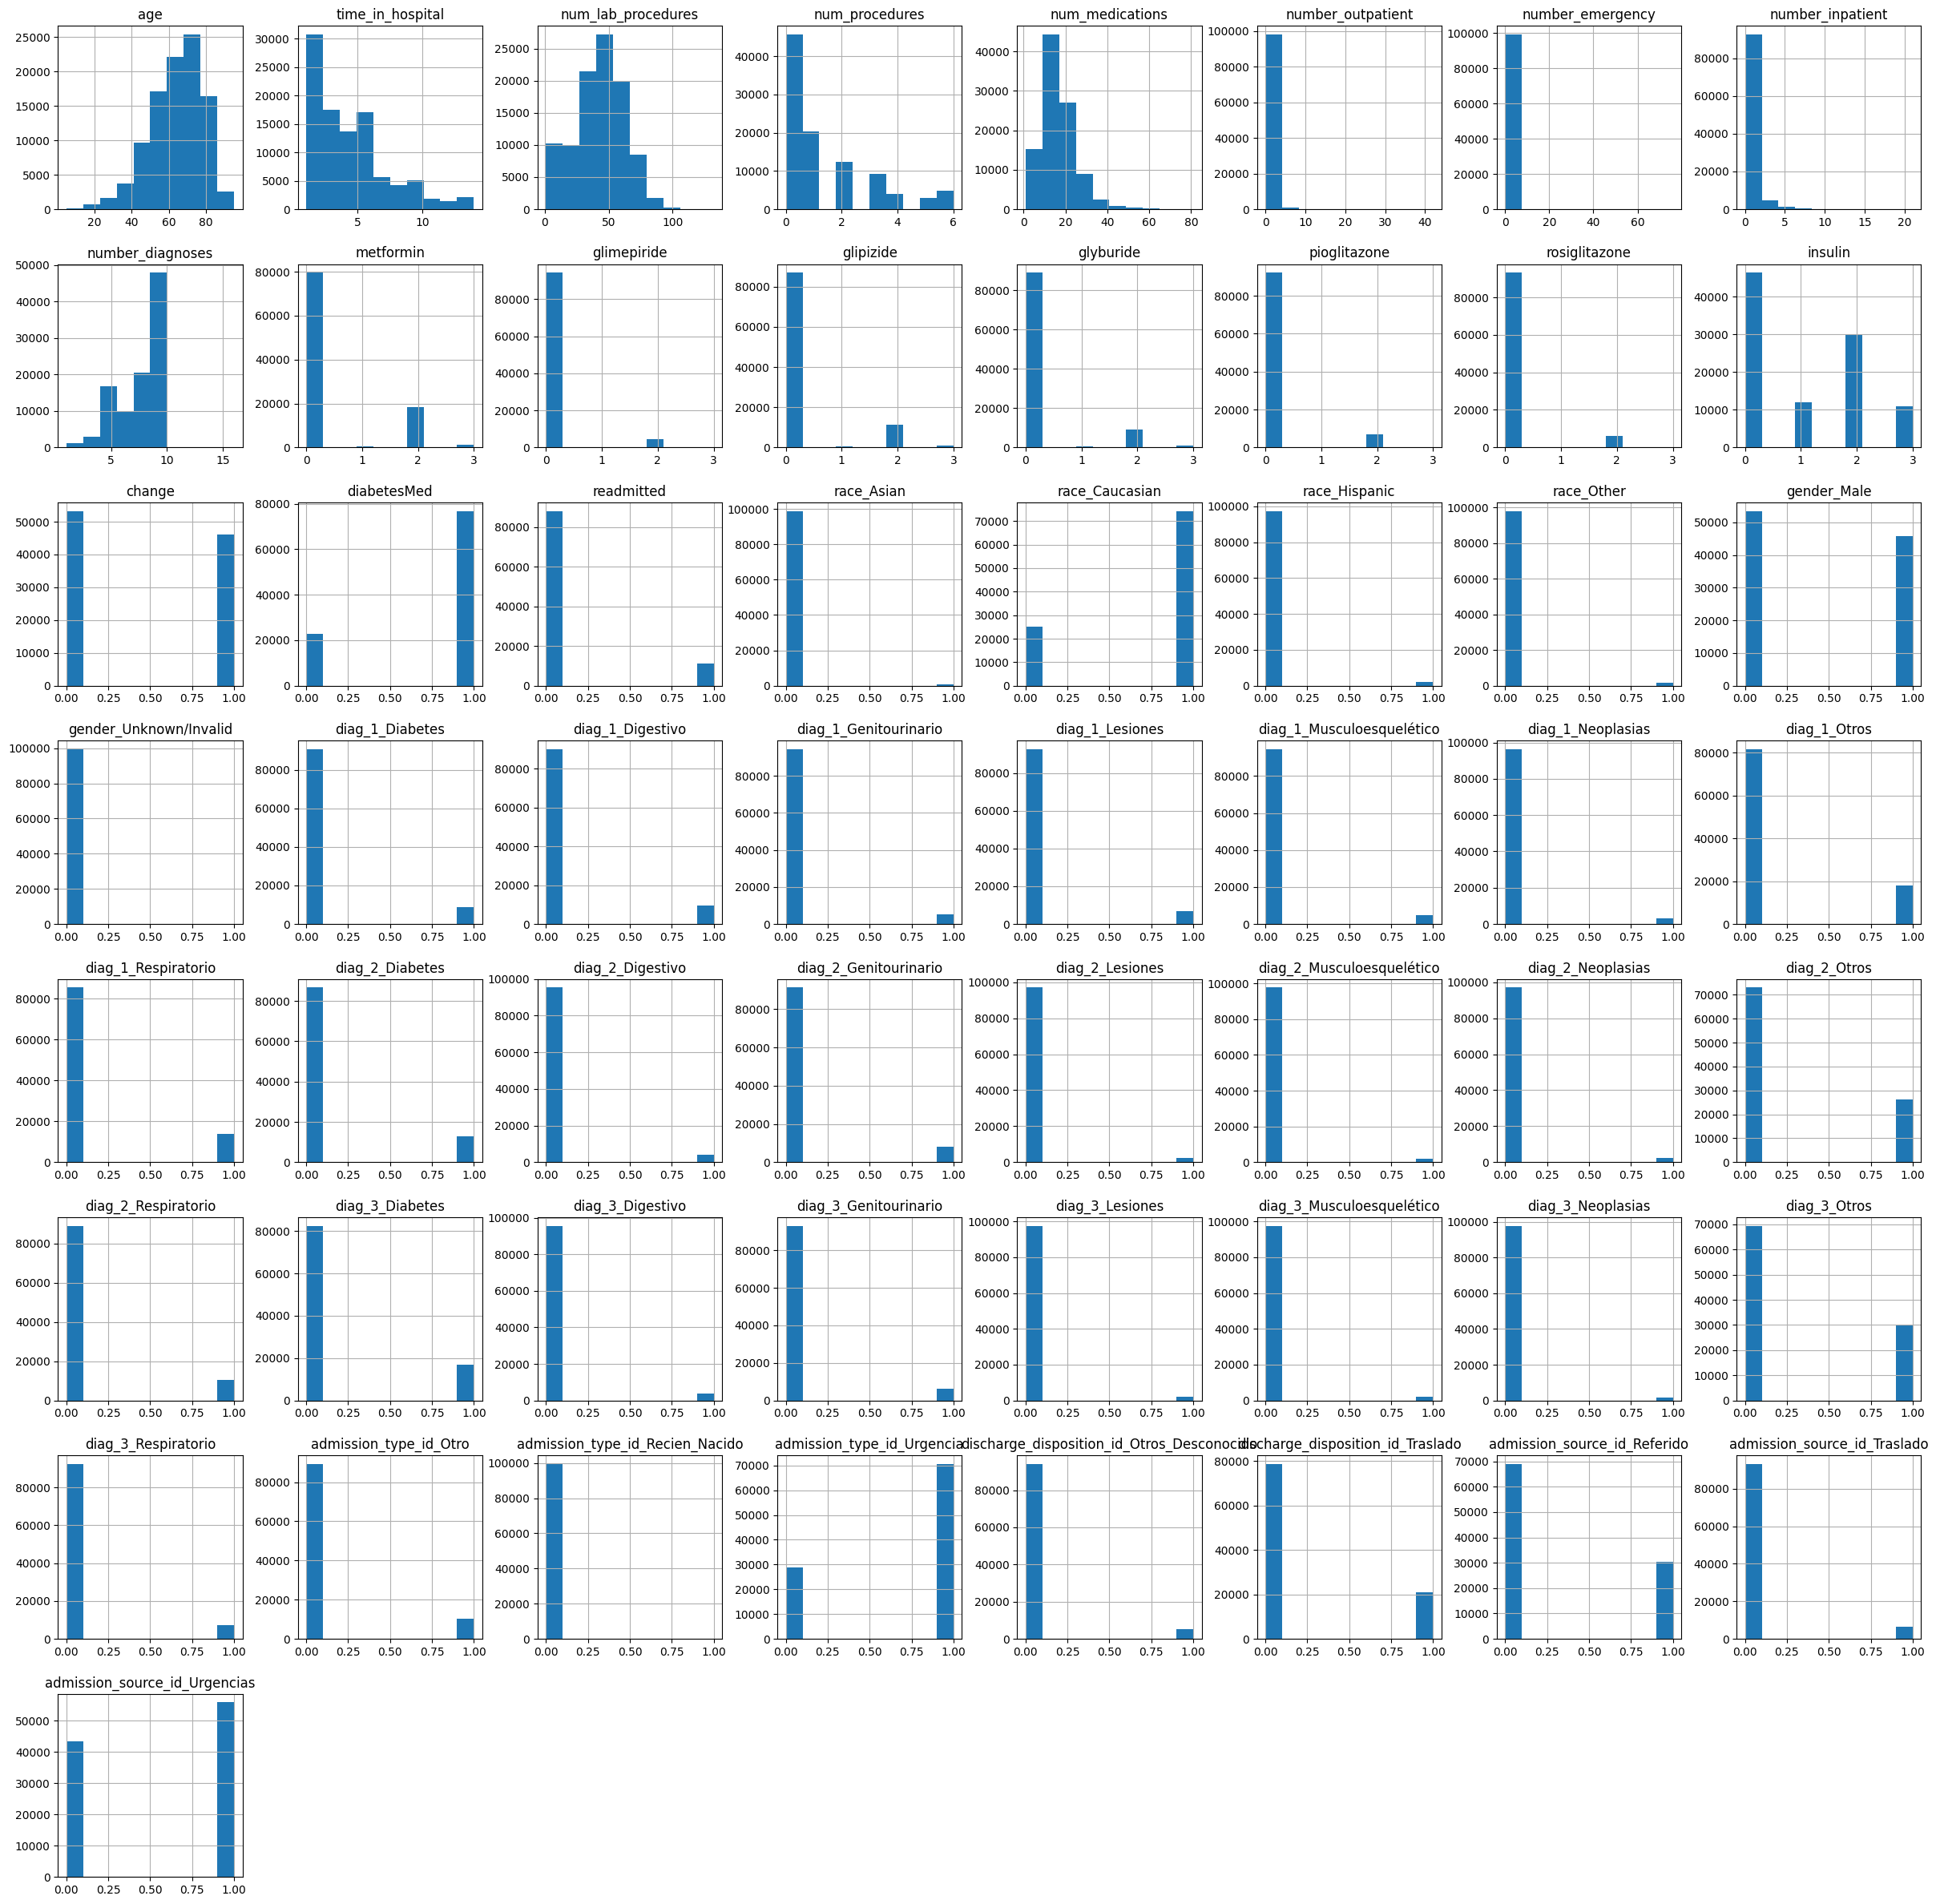

In [75]:
_ = datos.hist(figsize=(30, 30))

## Cuantficación objetivo

In [76]:
conteo = datos['readmitted'].value_counts()
porcentaje = datos['readmitted'].value_counts(normalize=True) * 100

print(f"Clase 0 (No readmitido): {conteo[0]} registros ({porcentaje[0]:.2f}%)")
print(f"Clase 1 (Readmitido): {conteo[1]} registros ({porcentaje[1]:.2f}%)")

Clase 0 (No readmitido): 88029 registros (88.61%)
Clase 1 (Readmitido): 11314 registros (11.39%)


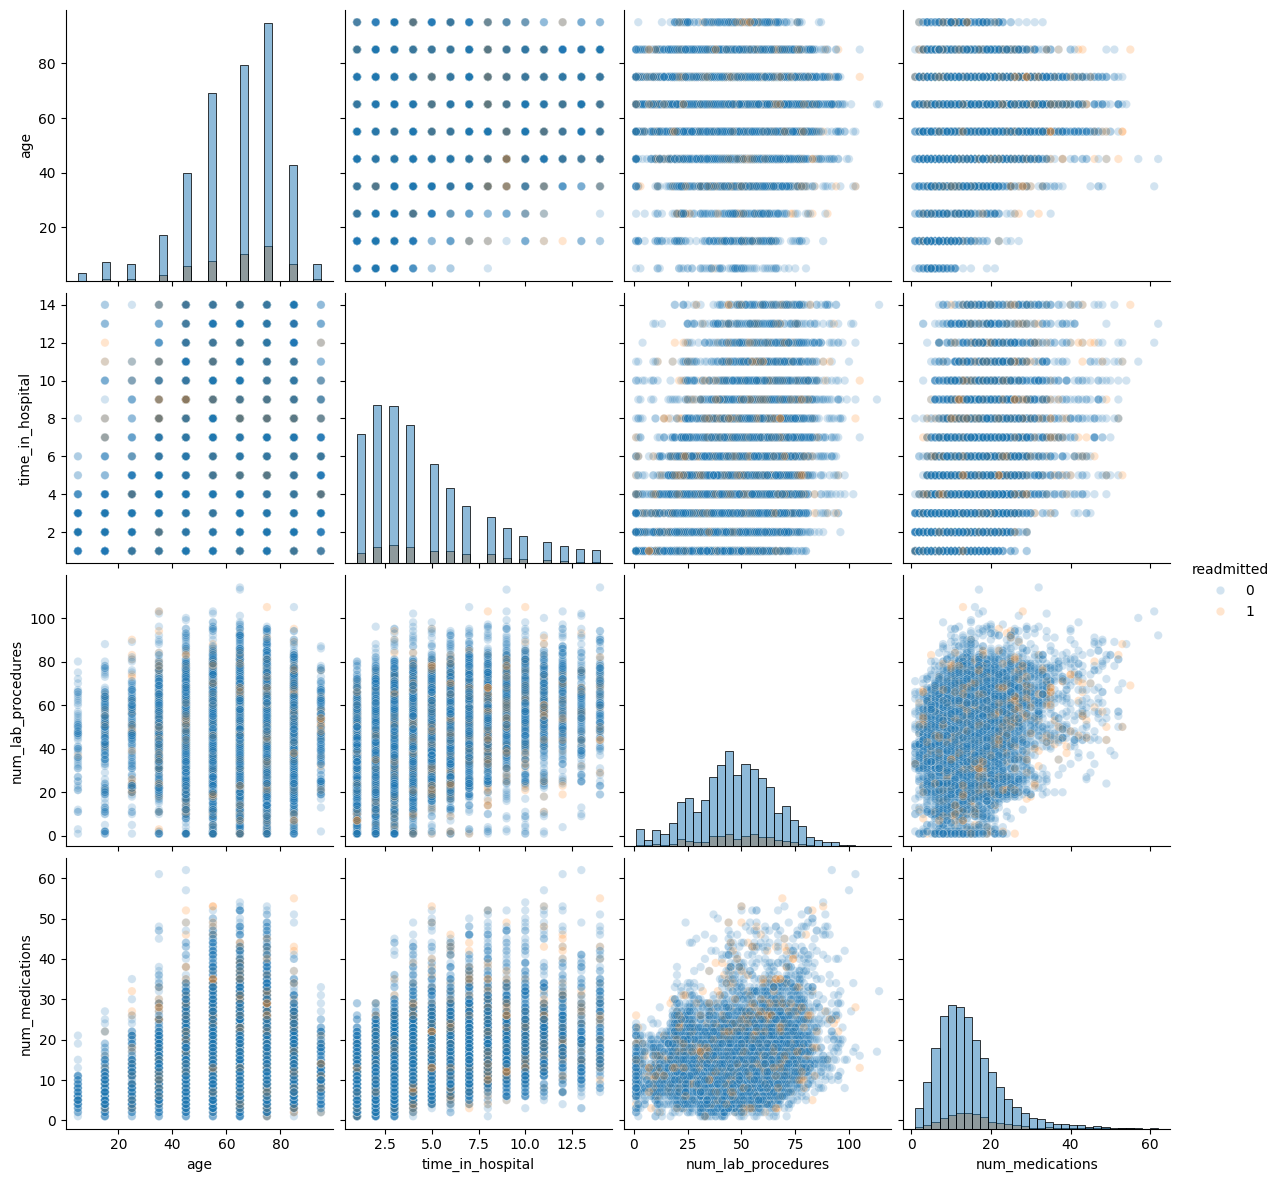

In [77]:

# We will plot a subset of the data to keep the plot readable and make the
# plotting faster
n_samples_to_plot = 10000
columns = ["age", "time_in_hospital", "num_lab_procedures", "num_medications"]
_ = sns.pairplot(
    data=datos[:n_samples_to_plot],
    vars=columns,
    hue="readmitted",
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30},
)

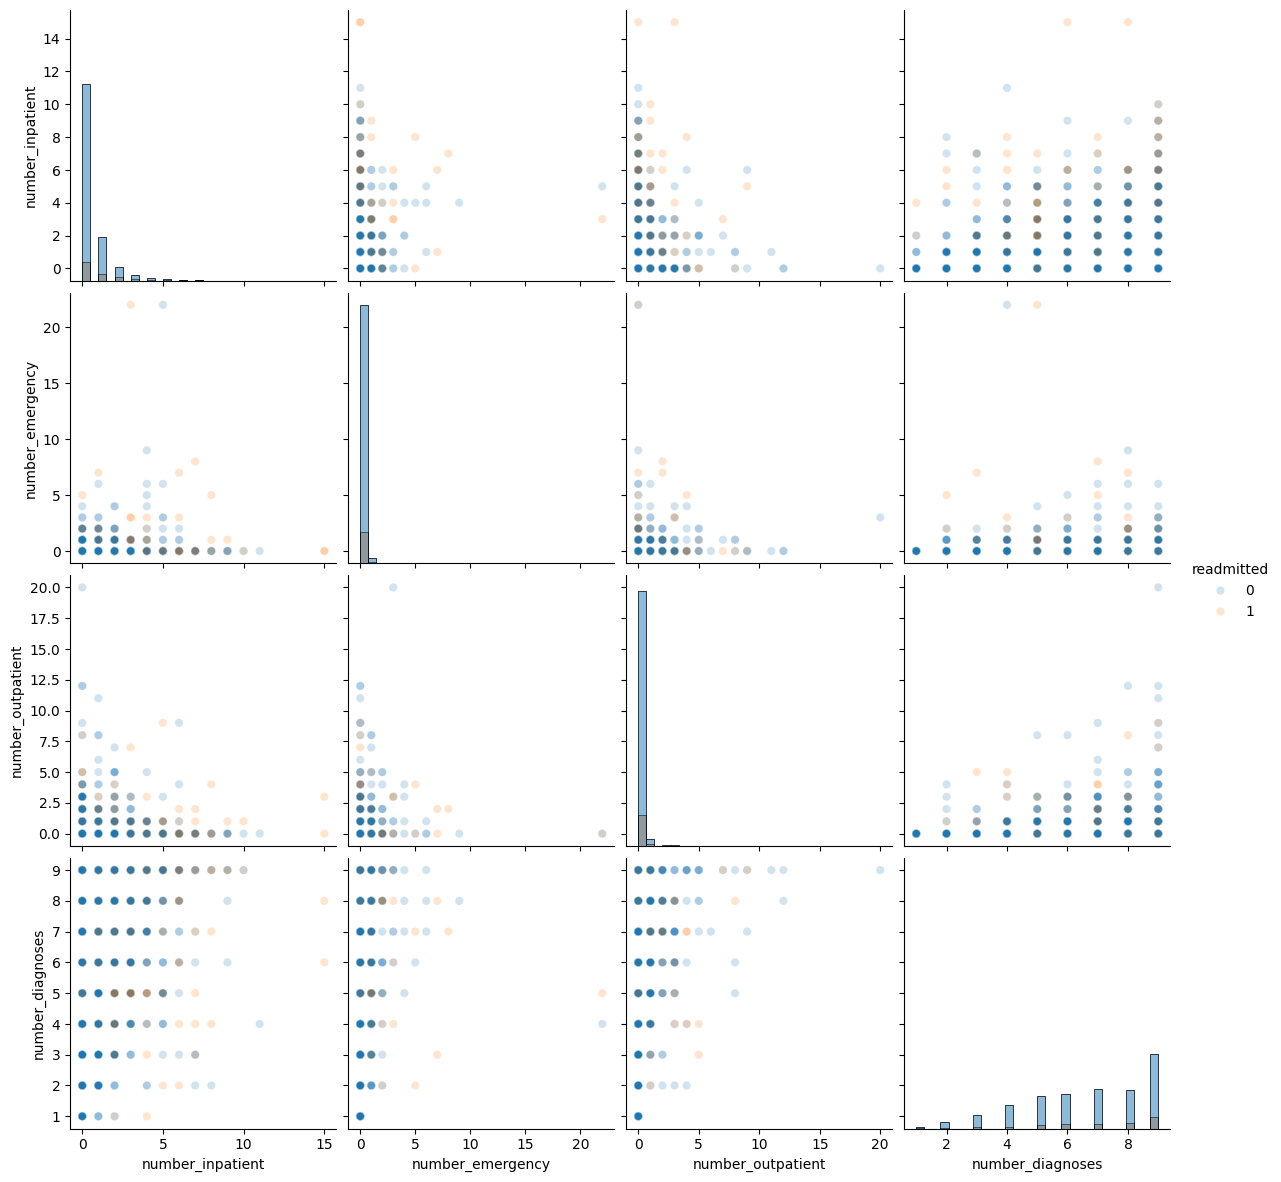

In [78]:

# We will plot a subset of the data to keep the plot readable and make the
# plotting faster
n_samples_to_plot = 10000
columns = ["number_inpatient", "number_emergency", "number_outpatient", "number_diagnoses"]
_ = sns.pairplot(
    data=datos[:n_samples_to_plot],
    vars=columns,
    hue="readmitted",
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30},
)

In [79]:
y = datos["readmitted"]
X = datos.drop(columns=["readmitted"])

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [81]:
dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)
print(f"Accuracy del dummy classifier: "
      f"{dummy_classifier.score(X_test, y_test):.3f}")

Accuracy del dummy classifier: 0.886


In [82]:
balanced_accuracy = balanced_accuracy_score(y_test, dummy_classifier.predict(X_test))
print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.500


In [83]:
scores = cross_val_score(dummy_classifier, X_train, y_train, cv=10, scoring='balanced_accuracy')

print(f"Balanced Accuracy medio (10-CV): {scores.mean():.3f}")

Balanced Accuracy medio (10-CV): 0.500


## Modelado inicial

In [89]:
logistic_regression = make_pipeline(
    StandardScaler(), 
    LogisticRegression(penalty=None, class_weight='balanced', max_iter=1000)
)

# Entrenamos
logistic_regression.fit(X_train, y_train)

# Evaluamos
accuracy = logistic_regression.score(X_test, y_test)
y_pred = logistic_regression.predict(X_test)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy en el set de test: {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))


Accuracy en el set de test: 0.665
Balanced Accuracy: 0.610

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17606
           1       0.18      0.54      0.27      2263

    accuracy                           0.67     19869
   macro avg       0.55      0.61      0.53     19869
weighted avg       0.84      0.67      0.72     19869

